# PAI test

## 1. Load the dataset

In [2]:
from re import L
from datasets import load_dataset
from huggingface_hub import snapshot_download
from PIL import Image

image_dir = "scratch/ows/.cache/huggingface/datasets/pai-bench/generation/condition_image"

image_dir = snapshot_download(
    repo_id="shi-labs/physical-ai-bench-generation",
    repo_type="dataset",
    allow_patterns="condition_image/*",
    local_dir=image_dir # Saves to your current working directory
)

ds = load_dataset("shi-labs/physical-ai-bench-generation")

Fetching ... files: 1044it [00:01, 600.86it/s]


In [ ]:
import os

first_row = ds['benchmark'][0]
img_name = first_row['image_name']
prompt = first_row['prompt']

# Construct the full local path and open the image
full_image_path = os.path.join(image_dir, "condition_image", img_name)
image = Image.open(full_image_path)
image

Error: no "view" rule for type "image/png" passed its test case
       (for more information, add "--debug=1" on the command line)


In [8]:
ds['benchmark'][0]

{'prompt_en': 'A video capturing a heavy rainfall in a tropical or subtropical environment. The scene opens with a close-up of a tree with large, broad leaves that are visibly wet and glistening under the rain. The leaves are attached to dark, slender branches that sway vigorously in the wind, indicating the strength of the storm. In the background, other trees with thinner trunks and more sparse foliage are partially obscured by the mist created by the rain, adding depth to the scene. The sky is overcast, contributing to the gray and damp atmosphere. As the video progresses, the rain continues to pour, with water droplets continuously falling and splashing against the leaves and branches. The leaves rustle and move more vigorously, and the branches bend further under the force of the wind. No new objects appear throughout the video; the focus remains on the interaction between the rain, wind, and vegetation. By the final frame, the scene retains its initial characteristics: the wet, s

## 2. Prepare the inference

Directly use CLI

In [2]:
from datasets import load_dataset
from huggingface_hub import snapshot_download
import sys,os


# setup
# Model                 Version             #Frames     FPS     Width   Height
# Cosmos-Predict2.5-2B  base/post-trained   93          16      1280    704

# output_dir
# /path/to/your/videos/
# ├── {video_id}__{seed}.mp4
# ├── {video_id}__{seed}.mp4
# └── ... (more video files following the naming pattern)

# example
# {'prompt_en': 'A video capturing a heavy rainfall in a tropical or subtropical environment. The scene opens with a close-up of a tree with large, broad leaves that are visibly wet and glistening under the rain. The leaves are attached to dark, slender branches that sway vigorously in the wind, indicating the strength of the storm. In the background, other trees with thinner trunks and more sparse foliage are partially obscured by the mist created by the rain, adding depth to the scene. The sky is overcast, contributing to the gray and damp atmosphere. As the video progresses, the rain continues to pour, with water droplets continuously falling and splashing against the leaves and branches. The leaves rustle and move more vigorously, and the branches bend further under the force of the wind. No new objects appear throughout the video; the focus remains on the interaction between the rain, wind, and vegetation. By the final frame, the scene retains its initial characteristics: the wet, swaying leaves, the misty background, and the persistent, heavy rain, maintaining the overall mood of a stormy day.',
#  'dimension': ['aesthetic_quality',
#   'background_consistency',
#   'imaging_quality',
#   'motion_smoothness',
#   'overall_consistency',
#   'subject_consistency',
#   'i2v_background',
#   'i2v_subject'],
#  'image_name': 'misc_933704-uhd_3840_2160_30fps.jpg',
#  'reference_video': 'misc_933704-uhd_3840_2160_30fps.mp4',
#  'video_id': 'misc_933704-uhd_3840_2160_30fps'}


class PAIGEvalMaker:
    def __init__(self, output_dir: str, hf_home: str = None):
        if hf_home is None:
            hf_home = os.environ.get("HF_HOME", os.path.expanduser("~/.cache/huggingface/datasets"))
        self.cache_dir = os.path.join(hf_home, "pai-bench", "generation")
        snapshot_download(
            repo_id="shi-labs/physical-ai-bench-generation",
            repo_type="dataset",
            allow_patterns="condition_image/*",
            local_dir=self.cache_dir 
        )
        self.ds = load_dataset("shi-labs/physical-ai-bench-generation")
        self.output_dir = output_dir
        os.makedirs(output_dir, exist_ok=True)
    
    @property
    def length(self):
        return len(self.ds['benchmark'])

    @property
    def image_dir(self):
        return os.path.join(self.cache_dir, "condition_image")

    def get_cosmos_predict_json(self, index, seed=0):
        row = self.ds['benchmark'][index]
        video_id = row['video_id']
        image_name = row['image_name']
        image_path = os.path.join(self.image_dir, image_name)
        prompt = row['prompt_en']
        return {
            "inference_type": "image2world",
            "name": f"{video_id}__{seed}",
            "model": "2B/post-trained",
            "num_output_frames": 93,
            "resolution": "1280,704",
            "input_path": image_path,
            "prompt": prompt,
            "output_dir": self.output_dir
        }

hf_home = "/scratch/ows/.cache/huggingface/datasets"
output_dir = "/scratch/ows/cosmos-predict2.5/outputs/pai_eval_output/test"

paig_maker = PAIGEvalMaker(output_dir, hf_home)



Fetching ... files: 1044it [00:01, 603.62it/s]


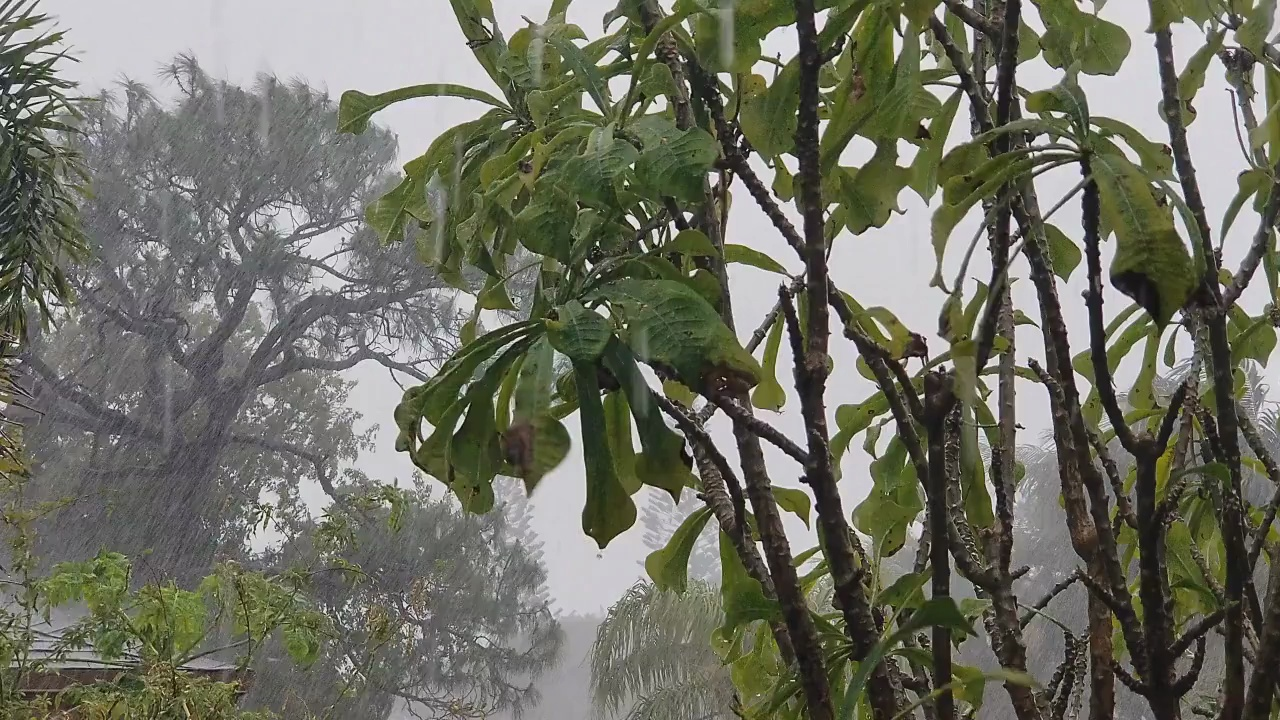

In [22]:
cfg = paig_maker.get_cosmos_predict_json(0)
img = Image.open(cfg['input_path'])
img
